<a href="https://colab.research.google.com/github/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/blob/main/Lab12/Lab12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio 12**

In [20]:
!pip install -q pmdarima arch

import yfinance as yf
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
from arch.univariate import ZeroMean, ARCH, GARCH, Normal

In [21]:
import warnings
warnings.filterwarnings('ignore')

In [22]:
# Descarga de datos
df = yf.download(['^VIX'], start='2018-01-01', end='2026-09-24')['Close']

[*********************100%***********************]  1 of 1 completed


## **Pregunta 1**

Grafica la serie del VIX y las ACF y PACF asociadas.

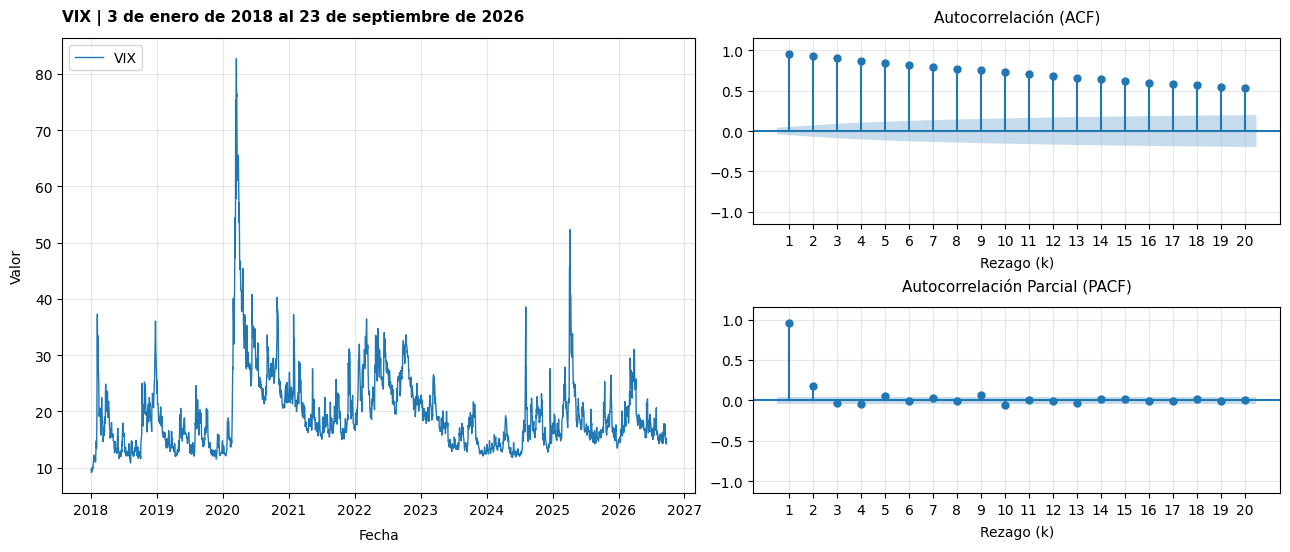

In [23]:
serie_vix = df["^VIX"].dropna()

# Gráficos
fig = plt.figure(figsize=(14, 5))

gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1], hspace=0.45, wspace=0.1)

lags_mostrar = 20

# COLUMNA 1: Serie del S&P 500
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(
    serie_vix.index,
    serie_vix.values,
    color="#1f77b4",
    linewidth=1,
    label="VIX"
)
ax1.set_title(
    'VIX | 3 de enero de 2018 al 23 de septiembre de 2026', loc='left',
    fontsize=11,
    fontweight="bold",
    pad=12,
)
ax1.set_xlabel("Fecha", labelpad=8)
ax1.set_ylabel("Valor", labelpad=8)
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# COLUMNA 2 (superior): ACF
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(
    serie_vix,
    ax=ax2,
    lags=lags_mostrar,
    zero=False,
    title="Autocorrelación (ACF)",
)
ax2.set_title("Autocorrelación (ACF)", fontsize=11, pad=12)
ax2.set_xlabel("Rezago (k)", labelpad=6)
ax2.set_xticks(range(1, lags_mostrar + 1))

ax2.set_ylim(-1.15, 1.15)
ax2.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax2.grid(True, alpha=0.3)

# COLUMNA 2 (Inferior): PACF
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(
    serie_vix,
    ax=ax3,
    lags=lags_mostrar,
    zero=False,
    title="Autocorrelación Parcial (PACF)",
    method="ywm",
)
ax3.set_title("Autocorrelación Parcial (PACF)", fontsize=11, pad=12)
ax3.set_xlabel("Rezago (k)", labelpad=6)
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.15, 1.15)
ax3.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax3.grid(True, alpha=0.3)


plt.subplots_adjust(top=0.92, bottom=0.01, left=0.08, right=0.95)

plt.show()

## **Pregunta 2**

Estima un modelo ARIMA para la serie del VIX.

In [24]:
modelo_vix_bic = pm.auto_arima(
    serie_vix, start_p=0, start_q=0, max_p=3, max_q=3,
    d=0, seasonal=False, information_criterion='bic',
    stepwise=True, suppress_warnings=True
)

print(f'Modelo óptimo por BIC: ARIMA{modelo_vix_bic.order}')
print(modelo_vix_bic.summary())

Modelo óptimo por BIC: ARIMA(1, 0, 2)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2195
Model:               SARIMAX(1, 0, 2)   Log Likelihood               -4666.253
Date:                Fri, 02 Oct 2026   AIC                           9342.505
Time:                        13:46:00   BIC                           9370.975
Sample:                             0   HQIC                          9352.909
                               - 2195                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.6351      0.093      6.833      0.000       0.453       0.817
ar.L1          0.9673      0.003    291.001      0.000       0.961       0.974
ma.L1         

## **Pregunta 3**

Obtiene los residuos del modelo ARIMA y ajusta un modelo GARCH(1,1) con distribución t-Student para capturar la estructura de volatilidad condicional y el exceso de curtosis de los residuos.

In [25]:
# Estimación sobre los residuos del ARIMA(1,0,2)

residuos_arima = pd.Series(modelo_vix_bic.resid()).dropna()

# 2. Ajustar el modelo ARCH / GARCH
model_vix = arch_model(
    residuos_arima,
    mean='Zero',
    vol='GARCH',
    p=1,
    q=1,
    dist='t'
)

res_vix = model_vix.fit(disp='off')
print(res_vix.summary())

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3828.59
Distribution:      Standardized Student's t   AIC:                           7665.17
Method:                  Maximum Likelihood   BIC:                           7687.95
                                              No. Observations:                 2195
Date:                      Fri, Oct 02 2026   Df Residuals:                     2195
Time:                              13:46:01   Df Model:                            0
                            Volatility Model                            
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          0

## **Pregunta 4**

Grafica la volatilidad condicional estimada.

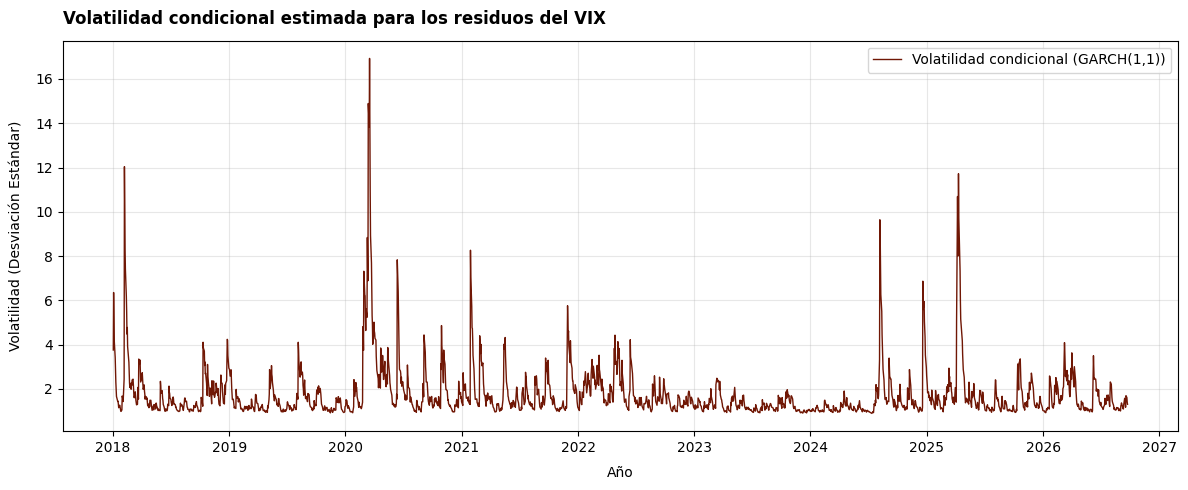

In [27]:
# Obtener la volatilidad condicional (desviación estándar condicional)
volatilidad_condicional = res_vix.conditional_volatility

# Graficar la volatilidad condicional estimada
plt.figure(figsize=(12, 5))
plt.plot(
    residuos_arima.index,
    volatilidad_condicional,
    color='#701705',
    linewidth=1,
    label='Volatilidad condicional (GARCH(1,1))'
)
plt.title(
    'Volatilidad condicional estimada para los residuos del VIX',
    loc='left',
    fontsize=12,
    fontweight='bold',
    pad=12
)
plt.xlabel('Año', labelpad=8)
plt.ylabel('Volatilidad (Desviación Estándar)', labelpad=8)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Pregunta 5**

Evalúa la calidad del ajuste con pruebas de residuos (Ljung-Box)

=== Prueba de Ljung-Box sobre Residuos Estandarizados ===


,lb_stat,lb_pvalue
10,21.816138,0.016069
15,24.163359,0.062371
20,26.802222,0.140921



=== Prueba de Ljung-Box sobre Residuos Estandarizados al Cuadrado ===


,lb_stat,lb_pvalue
10,1.838951,0.997432
15,3.154644,0.999452
20,9.758238,0.972347


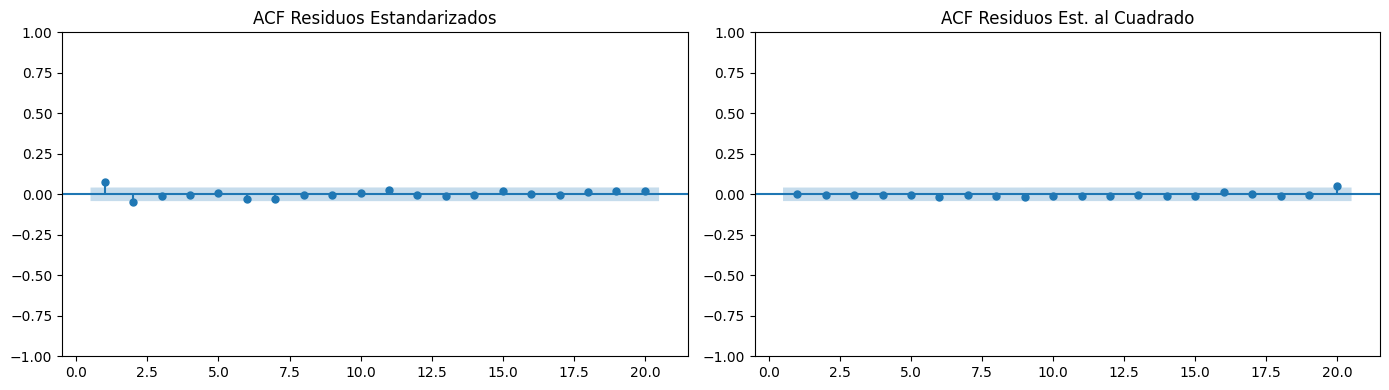

In [28]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Calcular los residuos estandarizados
residuos_estandarizados = res_vix.resid / res_vix.conditional_volatility

# 2. Aplicar la prueba de Ljung-Box sobre los residuos estandarizados (autocorrelación lineal)
print("=== Prueba de Ljung-Box sobre Residuos Estandarizados ===")
ljung_box_res = acorr_ljungbox(residuos_estandarizados, lags=[10, 15, 20], return_df=True)
display(ljung_box_res)

# 3. Aplicar la prueba de Ljung-Box sobre los residuos estandarizados al cuadrado (efectos ARCH restantes)
print("\n=== Prueba de Ljung-Box sobre Residuos Estandarizados al Cuadrado ===")
ljung_box_sq = acorr_ljungbox(residuos_estandarizados**2, lags=[10, 15, 20], return_df=True)
display(ljung_box_sq)

# 4. Graficar ACF de ambos para inspección visual
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuos_estandarizados, ax=axes[0], lags=20, zero=False, title="ACF Residuos Estandarizados")
plot_acf(residuos_estandarizados**2, ax=axes[1], lags=20, zero=False, title="ACF Residuos Est. al Cuadrado")
plt.tight_layout()
plt.show()

**Notas:**

(1) El hecho de que la prueba de Ljung-Box para los residuos estandarizados al cuadrado tenga un p-valor cercano a $1.00$ significa que se ha removido con éxito los efectos ARCH (el agrupamiento de volatilidad o *volatility clustering*).

(2) La ausencia de heterocedasticidad condicional en los residuos estandarizados valida que el supuesto de volatilidad dinámica modela correctamente la incertidumbre temporal.
